In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
print("LINEAR REGRESSION ASSIGNMENT - CAR SALES PRICE PREDICTION")
print("=" * 60)

LINEAR REGRESSION ASSIGNMENT - CAR SALES PRICE PREDICTION


In [5]:
try:
    df_raw = pd.read_csv("Car_sales.csv")
except FileNotFoundError:
    df_raw = pd.read_csv("/mnt/data/Car_sales.csv")
except UnicodeDecodeError:
    df_raw = pd.read_csv("Car_sales.csv", encoding="latin1")

df = df_raw.copy()

In [ ]:
print("PART A")
print("=" * 60)
print("First 5 rows")
print("-" * 60)
print(df.head())

PART A: DATA UNDERSTANDING
First 5 rows
------------------------------------------------------------
  Manufacturer    Model  Sales_in_thousands  __year_resale_value Vehicle_type  \
0        Acura  Integra              16.919               16.360    Passenger   
1        Acura       TL              39.384               19.875    Passenger   
2        Acura       CL              14.114               18.225    Passenger   
3        Acura       RL               8.588               29.725    Passenger   
4         Audi       A4              20.397               22.255    Passenger   

   Price_in_thousands  Engine_size  Horsepower  Wheelbase  Width  Length  \
0               21.50          1.8       140.0      101.2   67.3   172.4   
1               28.40          3.2       225.0      108.1   70.3   192.9   
2                 NaN          3.2       225.0      106.9   70.6   192.0   
3               42.00          3.5       210.0      114.6   71.4   196.6   
4               23.99          1

In [7]:
print("Dataset Information")
print("-" * 60)
df.info()

Dataset Information
------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         157 non-null    str    
 1   Model                157 non-null    str    
 2   Sales_in_thousands   157 non-null    float64
 3   __year_resale_value  121 non-null    float64
 4   Vehicle_type         157 non-null    str    
 5   Price_in_thousands   155 non-null    float64
 6   Engine_size          156 non-null    float64
 7   Horsepower           156 non-null    float64
 8   Wheelbase            156 non-null    float64
 9   Width                156 non-null    float64
 10  Length               156 non-null    float64
 11  Curb_weight          155 non-null    float64
 12  Fuel_capacity        156 non-null    float64
 13  Fuel_efficiency      154 non-null    float64
 14  Latest_Launch       

In [39]:
print("Statistical Summary")
print("-" * 60)
print(df.describe())

Statistical Summary
------------------------------------------------------------
       Sales_in_thousands  __year_resale_value  Price_in_thousands  \
count          155.000000           155.000000          155.000000   
mean            53.245832            17.118871           27.390755   
min              0.110000             5.160000            9.235000   
25%             14.074500            12.510000           18.017500   
50%             29.450000            14.010000           22.799000   
75%             68.183500            17.807500           31.947500   
max            540.561000            67.550000           85.500000   
std             68.397550            10.254111           14.351653   

       Engine_size  Horsepower   Wheelbase       Width      Length  \
count   155.000000  155.000000  155.000000  155.000000  155.000000   
mean      3.060000  185.696774  107.490968   71.153548  187.313548   
min       1.000000   55.000000   92.600000   62.600000  149.400000   
25%     

In [9]:
print("Dataset Shape")
print("-" * 60)
print(df.shape)

Dataset Shape
------------------------------------------------------------
(157, 16)


In [10]:
print("Column Names")
print("-" * 60)
print(df.columns)

Column Names
------------------------------------------------------------
Index(['Manufacturer', 'Model', 'Sales_in_thousands', '__year_resale_value',
       'Vehicle_type', 'Price_in_thousands', 'Engine_size', 'Horsepower',
       'Wheelbase', 'Width', 'Length', 'Curb_weight', 'Fuel_capacity',
       'Fuel_efficiency', 'Latest_Launch', 'Power_perf_factor'],
      dtype='str')


In [11]:
print("Missing Values Count")
print("-" * 60)
print(df.isnull().sum())

Missing Values Count
------------------------------------------------------------
Manufacturer            0
Model                   0
Sales_in_thousands      0
__year_resale_value    36
Vehicle_type            0
Price_in_thousands      2
Engine_size             1
Horsepower              1
Wheelbase               1
Width                   1
Length                  1
Curb_weight             2
Fuel_capacity           1
Fuel_efficiency         3
Latest_Launch           0
Power_perf_factor       2
dtype: int64


In [12]:
print("Percentage of Missing Values")
print("-" * 60)
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

Percentage of Missing Values
------------------------------------------------------------
Manufacturer            0.000000
Model                   0.000000
Sales_in_thousands      0.000000
__year_resale_value    22.929936
Vehicle_type            0.000000
Price_in_thousands      1.273885
Engine_size             0.636943
Horsepower              0.636943
Wheelbase               0.636943
Width                   0.636943
Length                  0.636943
Curb_weight             1.273885
Fuel_capacity           0.636943
Fuel_efficiency         1.910828
Latest_Launch           0.000000
Power_perf_factor       1.273885
dtype: float64


In [13]:
print("Data Types")
print("-" * 60)
print(df.dtypes)

Data Types
------------------------------------------------------------
Manufacturer               str
Model                      str
Sales_in_thousands     float64
__year_resale_value    float64
Vehicle_type               str
Price_in_thousands     float64
Engine_size            float64
Horsepower             float64
Wheelbase              float64
Width                  float64
Length                 float64
Curb_weight            float64
Fuel_capacity          float64
Fuel_efficiency        float64
Latest_Launch              str
Power_perf_factor      float64
dtype: object


In [14]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns
categorical_features = df.select_dtypes(include=["object"]).columns

print("Numerical Features")
print("-" * 60)
print(numerical_features)

print("\nCategorical Features")
print("-" * 60)
print(categorical_features)

Numerical Features
------------------------------------------------------------
Index(['Sales_in_thousands', '__year_resale_value', 'Price_in_thousands',
       'Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length',
       'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency', 'Power_perf_factor'],
      dtype='str')

Categorical Features
------------------------------------------------------------
Index(['Manufacturer', 'Model', 'Vehicle_type', 'Latest_Launch'], dtype='str')


C:\Users\varsh\AppData\Local\Temp\ipykernel_31968\3508974102.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=["object"]).columns


In [15]:
print("PART B: DATA CLEANING")
print("=" * 60)

df.columns = df.columns.str.strip()

print("Duplicate Rows")
print("-" * 60)
print(df.duplicated().sum())

df = df.drop_duplicates()

print("\nDuplicate Rows After Removing")
print("-" * 60)
print(df.duplicated().sum())

PART B: DATA CLEANING
Duplicate Rows
------------------------------------------------------------
0

Duplicate Rows After Removing
------------------------------------------------------------
0


In [16]:
df["Latest_Launch"] = pd.to_datetime(df["Latest_Launch"], errors="coerce")

target_column = "Price_in_thousands"

df = df.dropna(subset=[target_column])

print("Missing values after dropping missing target")
print("-" * 60)
print(df.isnull().sum())

Missing values after dropping missing target
------------------------------------------------------------
Manufacturer            0
Model                   0
Sales_in_thousands      0
__year_resale_value    36
Vehicle_type            0
Price_in_thousands      0
Engine_size             0
Horsepower              0
Wheelbase               0
Width                   0
Length                  0
Curb_weight             1
Fuel_capacity           0
Fuel_efficiency         2
Latest_Launch           0
Power_perf_factor       0
dtype: int64


In [17]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

categorical_columns = df.select_dtypes(include=["object"]).columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("Missing values after cleaning")
print("-" * 60)
print(df.isnull().sum())

Missing values after cleaning
------------------------------------------------------------
Manufacturer           0
Model                  0
Sales_in_thousands     0
__year_resale_value    0
Vehicle_type           0
Price_in_thousands     0
Engine_size            0
Horsepower             0
Wheelbase              0
Width                  0
Length                 0
Curb_weight            0
Fuel_capacity          0
Fuel_efficiency        0
Latest_Launch          0
Power_perf_factor      0
dtype: int64


C:\Users\varsh\AppData\Local\Temp\ipykernel_31968\815434495.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


In [18]:
print("PART C: FEATURE ENGINEERING")
print("=" * 60)

current_year = 2026

df["Launch_Year"] = df["Latest_Launch"].dt.year
df["Car_Age"] = current_year - df["Launch_Year"]

print(df[["Latest_Launch", "Launch_Year", "Car_Age"]].head())

PART C: FEATURE ENGINEERING
  Latest_Launch  Launch_Year  Car_Age
0    2012-02-02         2012       14
1    2011-06-03         2011       15
3    2011-03-10         2011       15
4    2011-10-08         2011       15
5    2011-08-09         2011       15


In [19]:
print("PART D: EXPLORATORY DATA ANALYSIS")
print("=" * 60)

PART D: EXPLORATORY DATA ANALYSIS


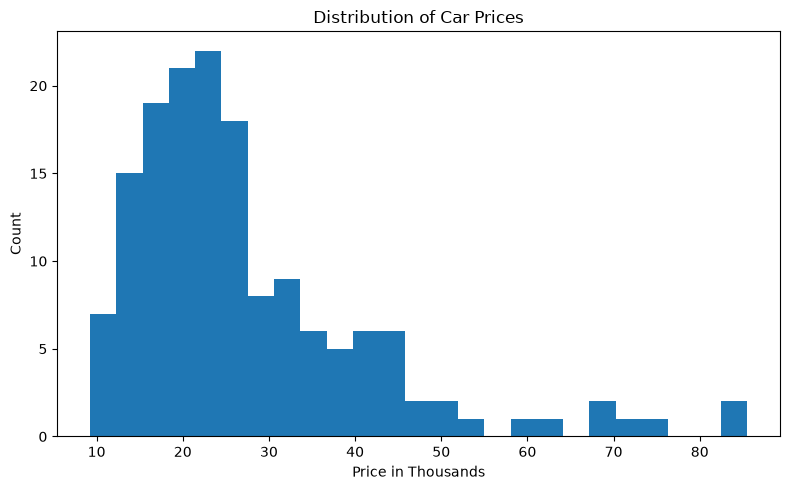

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(df["Price_in_thousands"], bins=25)
plt.xlabel("Price in Thousands")
plt.ylabel("Count")
plt.title("Distribution of Car Prices")
plt.tight_layout()
plt.show()

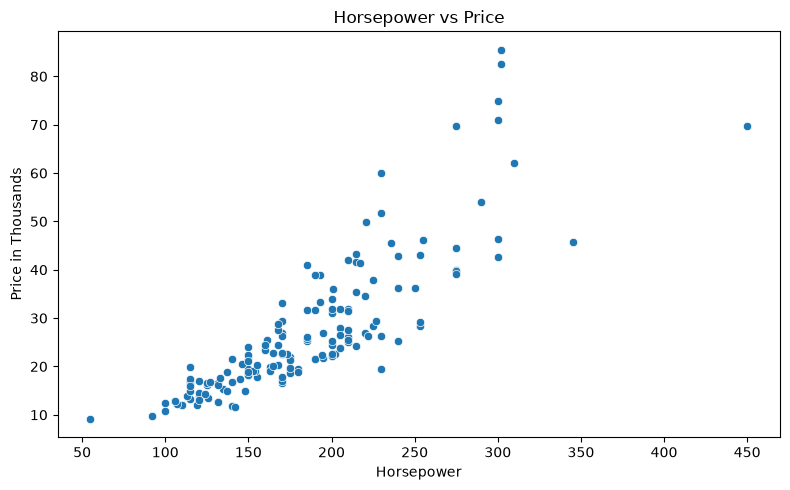

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Horsepower", y="Price_in_thousands", data=df)
plt.xlabel("Horsepower")
plt.ylabel("Price in Thousands")
plt.title("Horsepower vs Price")
plt.tight_layout()
plt.show()

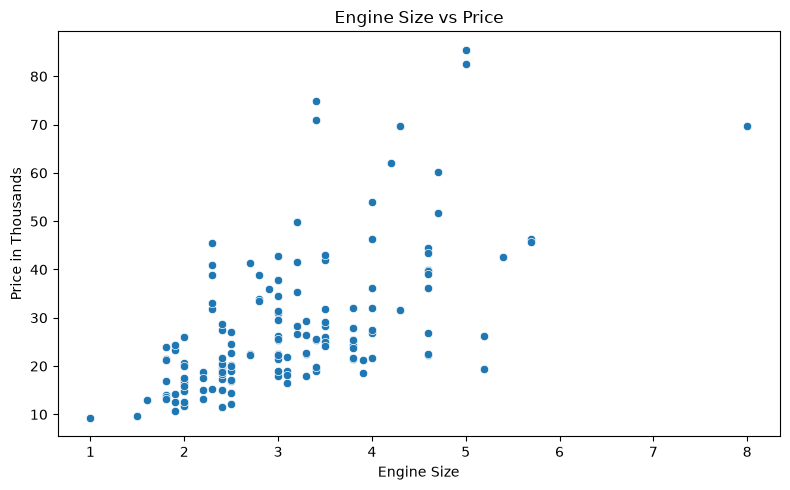

In [22]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Engine_size", y="Price_in_thousands", data=df)
plt.xlabel("Engine Size")
plt.ylabel("Price in Thousands")
plt.title("Engine Size vs Price")
plt.tight_layout()
plt.show()

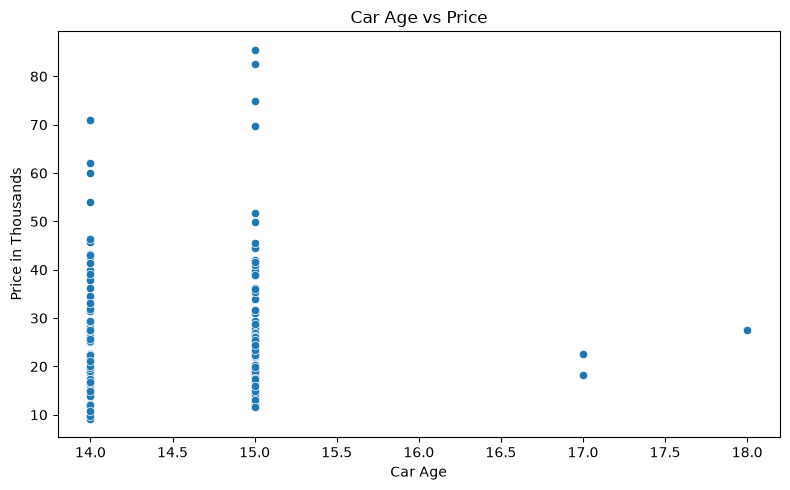

In [23]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Car_Age", y="Price_in_thousands", data=df)
plt.xlabel("Car Age")
plt.ylabel("Price in Thousands")
plt.title("Car Age vs Price")
plt.tight_layout()
plt.show()

Average Price by Vehicle Type
------------------------------------------------------------
Vehicle_type
Car          26.319975
Passenger    27.763200
Name: Price_in_thousands, dtype: float64


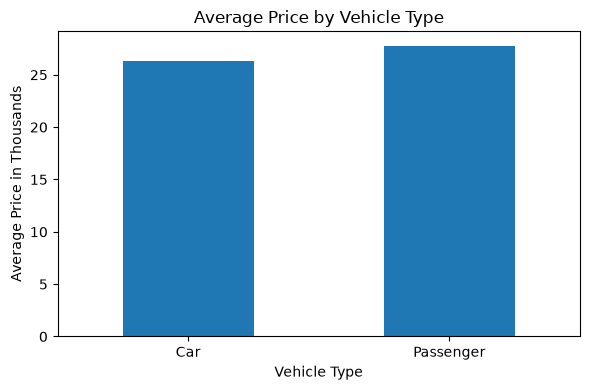

In [24]:
print("Average Price by Vehicle Type")
print("-" * 60)
vehicle_price = df.groupby("Vehicle_type")["Price_in_thousands"].mean()
print(vehicle_price)

plt.figure(figsize=(6, 4))
vehicle_price.plot(kind="bar")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Price in Thousands")
plt.title("Average Price by Vehicle Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Top 10 Manufacturers by Average Price
------------------------------------------------------------
Manufacturer
Porsche       62.473333
Mercedes-B    52.916667
Lexus         44.055000
Jaguar        42.800000
Lincoln       41.690000
Cadillac      40.254000
Audi          39.980000
BMW           33.096667
Volvo         30.933333
Acura         30.633333
Name: Price_in_thousands, dtype: float64


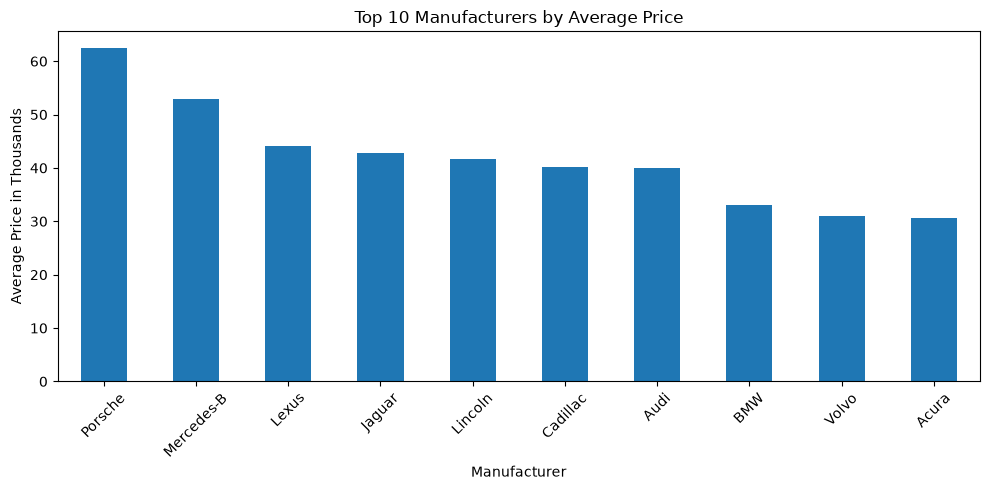

In [25]:
manufacturer_price = df.groupby("Manufacturer")["Price_in_thousands"].mean().sort_values(ascending=False).head(10)

print("Top 10 Manufacturers by Average Price")
print("-" * 60)
print(manufacturer_price)

plt.figure(figsize=(10, 5))
manufacturer_price.plot(kind="bar")
plt.xlabel("Manufacturer")
plt.ylabel("Average Price in Thousands")
plt.title("Top 10 Manufacturers by Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Correlation Table
------------------------------------------------------------
Price_in_thousands     1.000000
Power_perf_factor      0.897945
Horsepower             0.839744
__year_resale_value    0.783236
Engine_size            0.626875
Curb_weight            0.523329
Fuel_capacity          0.423282
Width                  0.329136
Length                 0.156935
Wheelbase              0.110513
Sales_in_thousands    -0.304734
Fuel_efficiency       -0.492028
Name: Price_in_thousands, dtype: float64


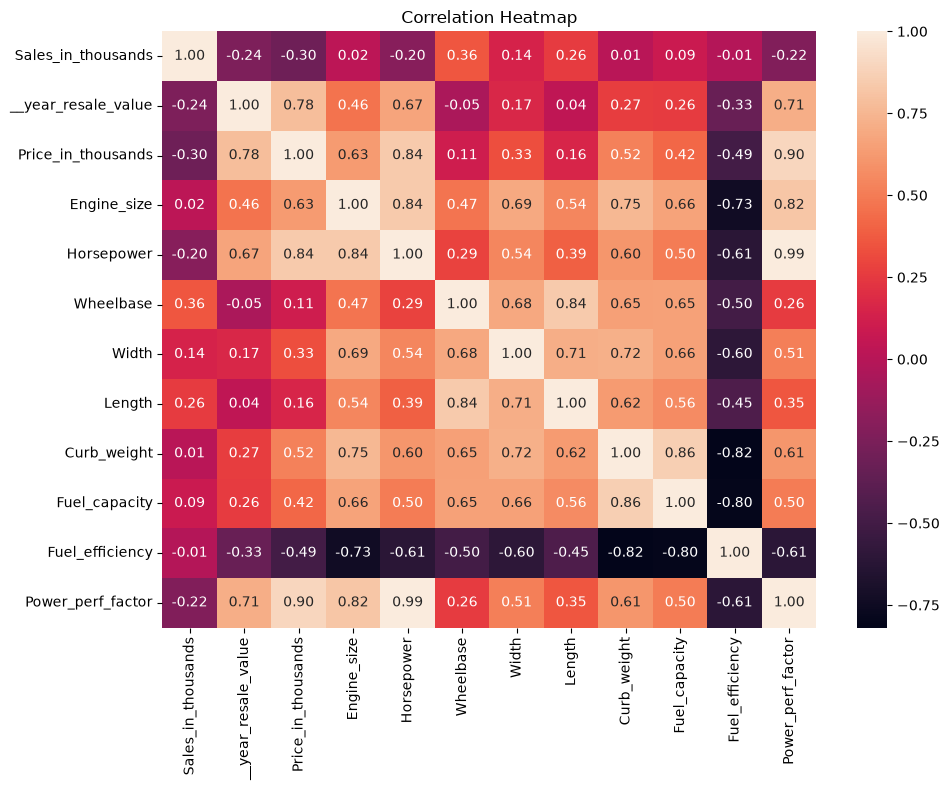

In [26]:
numeric_data = df.select_dtypes(include=["int64", "float64"])
correlation_table = numeric_data.corr()

print("Correlation Table")
print("-" * 60)
print(correlation_table["Price_in_thousands"].sort_values(ascending=False))

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_table, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [27]:
print("PART E: ENCODING CATEGORICAL VARIABLES")
print("=" * 60)

model_df = df.copy()

model_df = model_df.drop(columns=[
    "Model",
    "Latest_Launch",
    "Launch_Year",
    "Power_perf_factor"
], errors="ignore")

model_df = pd.get_dummies(model_df, columns=["Manufacturer", "Vehicle_type"], drop_first=True)

print("Encoded Dataset")
print("-" * 60)
print(model_df.head())

print("\nEncoded Data Types")
print("-" * 60)
print(model_df.dtypes)

PART E: ENCODING CATEGORICAL VARIABLES
Encoded Dataset
------------------------------------------------------------
   Sales_in_thousands  __year_resale_value  Price_in_thousands  Engine_size  \
0              16.919               16.360               21.50          1.8   
1              39.384               19.875               28.40          3.2   
3               8.588               29.725               42.00          3.5   
4              20.397               22.255               23.99          1.8   
5              18.780               23.555               33.95          2.8   

   Horsepower  Wheelbase  Width  Length  Curb_weight  Fuel_capacity  ...  \
0       140.0      101.2   67.3   172.4        2.639           13.2  ...   
1       225.0      108.1   70.3   192.9        3.517           17.2  ...   
3       210.0      114.6   71.4   196.6        3.850           18.0  ...   
4       150.0      102.6   68.2   178.0        2.998           16.4  ...   
5       200.0      108.7   76

In [28]:
print("PART F: TRAIN TEST SPLIT")
print("=" * 60)

X = model_df.drop(columns=["Price_in_thousands"])
y = model_df["Price_in_thousands"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape")
print("-" * 60)
print(X_train.shape)

print("\nTesting Data Shape")
print("-" * 60)
print(X_test.shape)

PART F: TRAIN TEST SPLIT
Training Data Shape
------------------------------------------------------------
(124, 41)

Testing Data Shape
------------------------------------------------------------
(31, 41)


In [29]:
print("PART G: TRAIN LINEAR REGRESSION MODEL")
print("=" * 60)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Model trained successfully")

PART G: TRAIN LINEAR REGRESSION MODEL
Model trained successfully


In [30]:
print("PART H: MODEL EVALUATION")
print("=" * 60)

y_pred = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error")
print("-" * 60)
print(mae)

print("\nMean Squared Error")
print("-" * 60)
print(mse)

print("\nRoot Mean Squared Error")
print("-" * 60)
print(rmse)

print("\nR2 Score")
print("-" * 60)
print(r2)

PART H: MODEL EVALUATION
Mean Absolute Error
------------------------------------------------------------
4.275997031466721

Mean Squared Error
------------------------------------------------------------
33.39780888409667

Root Mean Squared Error
------------------------------------------------------------
5.779083740879402

R2 Score
------------------------------------------------------------
0.844636151783253


In [31]:
metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Value": [mae, mse, rmse, r2]
})

print(metrics)

     Metric      Value
0       MAE   4.275997
1       MSE  33.397809
2      RMSE   5.779084
3  R2 Score   0.844636


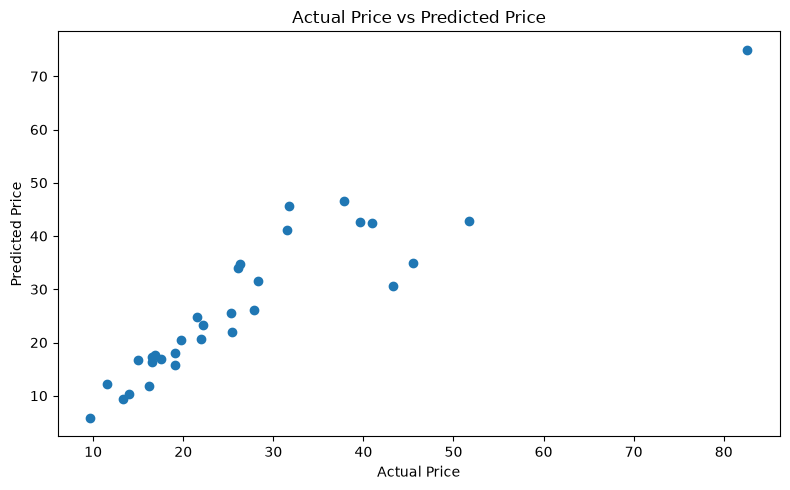

In [32]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")
plt.tight_layout()
plt.show()

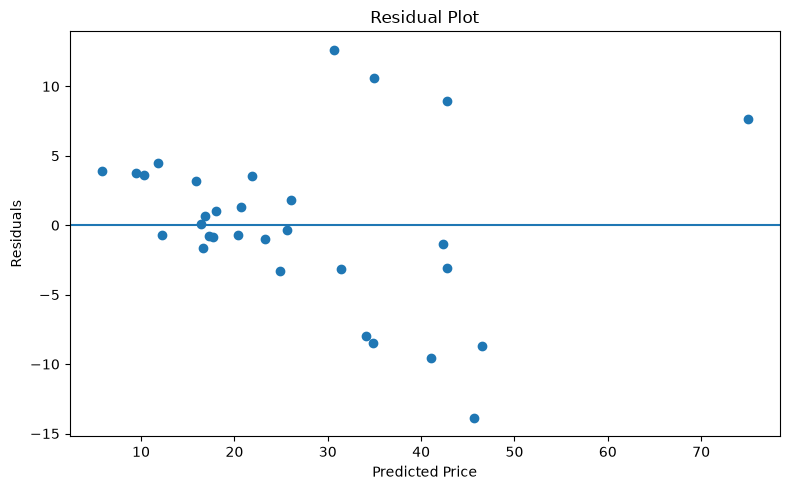

In [33]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

In [34]:
print("PART I: FEATURE IMPORTANCE USING COEFFICIENTS")
print("=" * 60)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Absolute Coefficient", ascending=False)

print(coef_df.head(15))

PART I: FEATURE IMPORTANCE USING COEFFICIENTS
                    Feature  Coefficient  Absolute Coefficient
33     Manufacturer_Porsche    15.350611             15.350611
26  Manufacturer_Mercedes-B    13.569300             13.569300
34        Manufacturer_Saab     9.632895              9.632895
22      Manufacturer_Jaguar     9.076083              9.076083
24       Manufacturer_Lexus     8.001083              8.001083
7               Curb_weight     5.707370              5.707370
15   Manufacturer_Chevrolet    -5.496185              5.496185
20     Manufacturer_Hyundai    -5.154815              5.154815
11        Manufacturer_Audi     5.018198              5.018198
23        Manufacturer_Jeep    -4.617027              4.617027
27     Manufacturer_Mercury    -4.288721              4.288721
13       Manufacturer_Buick    -3.897506              3.897506
32     Manufacturer_Pontiac    -3.862391              3.862391
21    Manufacturer_Infiniti    -3.488257              3.488257
17       

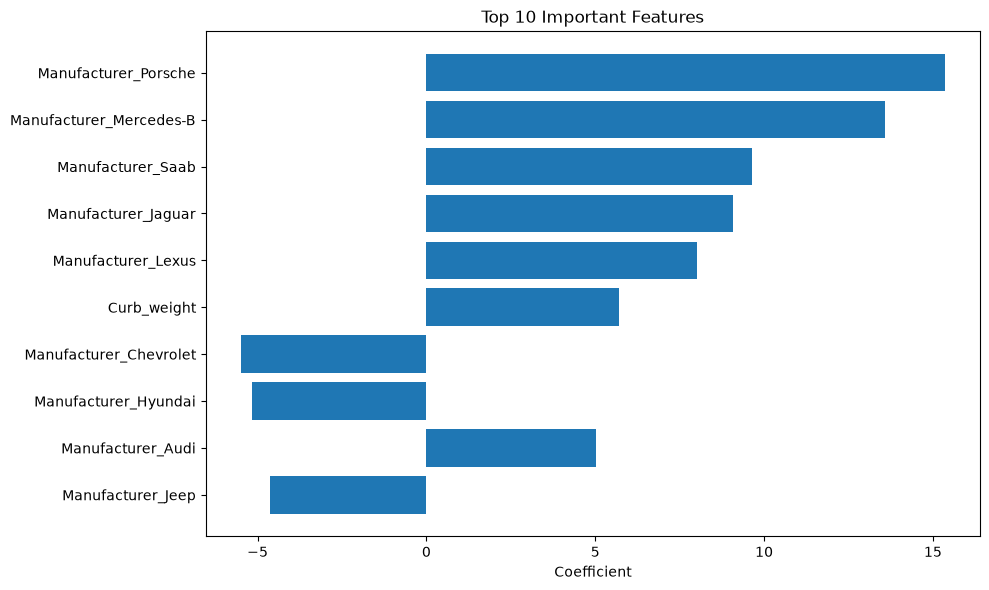

In [35]:
top_features = coef_df.head(10).sort_values(by="Absolute Coefficient")

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.xlabel("Coefficient")
plt.title("Top 10 Important Features")
plt.tight_layout()
plt.show()

In [36]:
print("PART J: QUESTIONS")
print("=" * 60)

top_feature = coef_df.iloc[0]["Feature"]

print("1. Which feature most influences selling price?")
print("-" * 60)
print(top_feature)

print("\n2. How does car age affect selling price?")
print("-" * 60)
car_age_coefficient = coef_df[coef_df["Feature"] == "Car_Age"]["Coefficient"].values[0]
print("Car Age Coefficient:", car_age_coefficient)

if car_age_coefficient < 0:
    print("As car age increases, selling price decreases.")
else:
    print("In this dataset, car age has a positive coefficient, but normally older cars sell for less.")

print("\n3. Is Linear Regression suitable for this dataset? Why?")
print("-" * 60)
print("Linear Regression is suitable as a basic starting model because the target variable is numerical.")
print("However, car price can also depend on non-linear relationships.")

print("\n4. What limitations did you observe?")
print("-" * 60)
print("The dataset is small, has some missing values, may contain outliers, and does not include condition or accident history.")

PART J: QUESTIONS
1. Which feature most influences selling price?
------------------------------------------------------------
Manufacturer_Porsche

2. How does car age affect selling price?
------------------------------------------------------------
Car Age Coefficient: 0.1833293214662509
In this dataset, car age has a positive coefficient, but normally older cars sell for less.

3. Is Linear Regression suitable for this dataset? Why?
------------------------------------------------------------
Linear Regression is suitable as a basic starting model because the target variable is numerical.
However, car price can also depend on non-linear relationships.

4. What limitations did you observe?
------------------------------------------------------------
The dataset is small, has some missing values, may contain outliers, and does not include condition or accident history.
